In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)

In [2]:
data = []

# CLEAN (0)
for _ in range(400):
    data.append([
        np.random.uniform(1, 100),      # Turbidity
        np.random.uniform(6.0, 8.5),    # pH
        np.random.uniform(50, 299),     # TDS
        0
    ])

# MODERATE (1)
for _ in range(400):
    data.append([
        np.random.uniform(1, 100),
        np.random.uniform(6.0, 8.5),
        np.random.uniform(300, 700),
        1
    ])

# CONTAMINATED (2)
for _ in range(400):
    choice = np.random.choice([0, 1, 2])

    if choice == 0:  # High turbidity
        data.append([np.random.uniform(101, 250), np.random.uniform(6, 8.5), np.random.uniform(50, 700), 2])

    elif choice == 1:  # Bad pH
        data.append([np.random.uniform(1, 100), np.random.uniform(2, 5.9), np.random.uniform(50, 700), 2])

    else:  # High TDS
        data.append([np.random.uniform(1, 100), np.random.uniform(6, 8.5), np.random.uniform(701, 1200), 2])

df = pd.DataFrame(data, columns=['Turbidity', 'pH', 'TDS', 'Label'])
df = df.sample(frac=1).reset_index(drop=True)

df.head()

,Turbidity,pH,TDS,Label
0,88.805565,7.614527,414.362716,1
1,25.475876,8.176875,478.122102,1
2,77.303511,7.068739,803.902485,2
3,78.779510,6.295840,463.961956,1
4,34.116618,6.065492,309.676706,1


In [3]:
def gini(counts):
    total = sum(counts)
    return 1 - sum((c/total)**2 for c in counts)

print("Gini =", gini([40, 30, 30]))

Gini = 0.6599999999999999


In [5]:
X = df[['Turbidity', 'pH', 'TDS']]
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [7]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        80
           2       1.00      1.00      1.00        80

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [8]:
cv = cross_val_score(model, X, y, cv=10)
print("CV Accuracy:", cv.mean())

CV Accuracy: 0.9975000000000002


In [9]:
samples = [
    [25, 7.1, 200],
    [60, 7.0, 500],
    [130, 5.5, 850]
]

labels = {0: 'CLEAN', 1: 'MODERATE', 2: 'CONTAMINATED'}

for s in samples:
    pred = model.predict([s])[0]
    print(s, "→", labels[pred])

[25, 7.1, 200] → CLEAN
[60, 7.0, 500] → MODERATE
[130, 5.5, 850] → CONTAMINATED


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


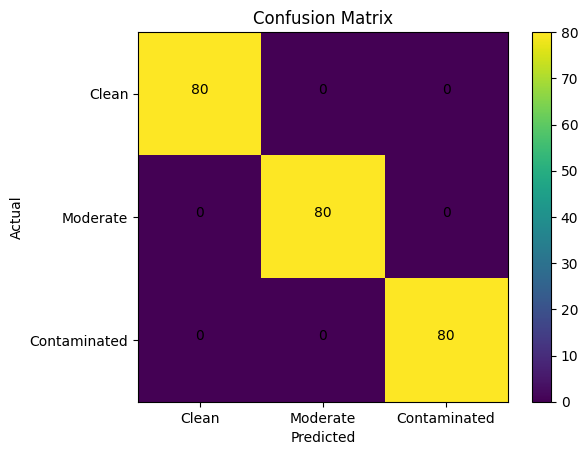

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1,2], ['Clean','Moderate','Contaminated'])
plt.yticks([0,1,2], ['Clean','Moderate','Contaminated'])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i][j], ha='center')

plt.show()